### Evasion dataset 

In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_regression
import joblib
import yaml
from pathlib import Path


In [3]:
# configs 
my_font = dict(
            family="Courier New, monospace",
            size=18,
            color="Black",
            variant="small-caps",
) 

## Loading datasets

In [4]:
"""
Loading the datasets

"""
def get_config_file(): 
    try:
        base_dir = Path(__file__).resolve().parent.parent
        path = base_dir / "configs" / "training.yaml"
        return path
    except NameError: # if it is a jupyter file 
        return Path("/training-app/configs/training.yaml")


def load_config(CONFIG_PATH) :
  """
  Selects the current dataset's config file we are interest in.
  """
  try:
      with open(CONFIG_PATH, "r") as f:
        full_config = yaml.safe_load(f)
  except Exception as e:
    print(f"Config file not found {e}")
    raise


  try:
    current_dataset = full_config["CURRENT_DATASET"]
    print(f"\nloading current dataset: {current_dataset}")
    if current_dataset not in full_config['DATASETS']:
      raise ValueError(f"\nDataset {current_dataset} not found!")

    return full_config["DATASETS"][current_dataset]

  except Exception as e:
    print(f"There was an error handling the config cleaning.yaml file {e}")
    raise


CONFIG_PATH = get_config_file()
dfs = load_config(CONFIG_PATH)


loading current dataset: CIENCIA_DA_COMPUTACAO


### Selecting desired dataset -> df_train


In [754]:
"""
Selecting desired dataset -> df_train
"""
df_train = pd.read_csv(dfs['TRAINING_DATASET'])
df_active = pd.read_csv(dfs['ACTIVE_DATASET'])
df_deactive = pd.read_csv(dfs['EVADED_DATASET'])
df_history = pd.read_csv(dfs['HISTORY_DATASET'])

## Checking the general info of the dataset

We need to extract the following features:
    - For each semester, we need to calculate the CR - Coeficiente de Rendimento
    - The total Amount of failings per semester 
    - The total Diciplines made per semester (Credits)
    - CR_Trend - Change in CR from last semester (Coeficiente)
    - Failure_rate - % of subjects failed so far
    - % of subjects failed so far
    - Delayed_Progress	Are they behind schedule?


- We must create the Lag_Academico
  - Tempo_de_Permanenca - Idade_Academica 
    - Lag 0   -> The student is on track
    - Lag > 2 -> The student is behind
    - Lag < 0 -> The student is an overachiever 

- We can also create the Velocidade_Progresso
  - ( Idade_Academica / Tempo_de_Permanencia )  
  - 1.0 -> velocidade ok
  - 0.5 -> Student taking 2x to finish the classes

## Handling History dataset - this later on will be a dag in airflow

In [842]:
df_history_v0 = df_history.copy()
def calculate_ano_sem(df: pd.DataFrame) -> pd.DataFrame:
    df['Ano']  = df['AnoSem'].astype('int')
    df['Parcela'] = df['Semestre'] / 10
    if 'AnoSem' in df.columns:
        df.drop(columns={'AnoSem'}, inplace=True)
    df['AnoSem'] = df['Ano'] + df['Parcela']
    return df
df_history_v0 = calculate_ano_sem(df_history_v0)
df_history_v0 = df_history_v0.sort_values(by='RGA_Anon')
df_history_v0.drop(columns={"Faltas", "Codigo_Turma", "Equivalencia", "Codigo_Disciplina", "Curso_Ofertante", "Observacao", "Ano", 'Idade_Academica'}, inplace=True)

"""
Here, we will need the - Período ingresso - feature to calculate the permanence time
"""

all_students = pd.concat([df_active, df_deactive], axis=0)
df_history_v0 = df_history_v0.merge(all_students[['RGA_Anon', 'Período ingresso', 'Estrutura', 'Situação atual']], on='RGA_Anon', how='left')


df_history_v0['Nome_Disciplina'] = (
    df_history_v0['Nome_Disciplina']
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
    .str.upper()
    .str.strip()
)

df_history_v0['Nome_Disciplina'] = df_history_v0['Nome_Disciplina'].str.replace(r'\(OPTATIVA\)', '', regex=True).str.strip()

In [845]:
def eliminating_duplicates_ap_ae(df: pd.DataFrame) -> pd.DataFrame:

    ae_ap_pairs = df.groupby(['RGA_Anon', 'Nome_Disciplina']) \
        .filter(lambda g: {'AP', 'AE'}.issubset(set(g['Situação'])))

    df_adjust = df.copy()

    nota_ap = ae_ap_pairs[ae_ap_pairs['Situação'] == 'AP'] \
        .groupby(['RGA_Anon', 'Nome_Disciplina'])['Nota'].max()

    mask_ae = (df_adjust['Situação'] == 'AE') & (
        df_adjust.set_index(['RGA_Anon', 'Nome_Disciplina']).index.isin(nota_ap.index)
    )

    df_adjust.loc[mask_ae, 'Nota'] = df_adjust.loc[mask_ae].set_index(
        ['RGA_Anon', 'Nome_Disciplina']
    ).index.map(nota_ap)

    mask_ap_to_drop = (df_adjust['Situação'] == 'AP') & (
        df_adjust.set_index(['RGA_Anon', 'Nome_Disciplina']).index.isin(nota_ap.index)
    )

    df_adjust = df_adjust[~mask_ap_to_drop].copy()
    return df_adjust

df_history_v0 =  eliminating_duplicates_ap_ae(df_history_v0)


In [846]:
"""
Here, we'll consider failure to a subject as 1 and non-failure as 0
    - MA will be disconsidered

"""
df_history_v0 = df_history_v0[df_history_v0['Situação'] != "MA"]
failures = ['RMF', 'RM', 'RP', 'RF']

df_history_v0['Situação']  = np.where(
    df_history_v0['Situação'].isin(failures),
    1,
    0
)

In [847]:
"""
Here we calculate the weighted faiulure - Reprovacao_Ponderada_Semestral - How many credits did the student fail
"""
def calculate_weighted_failured( df: pd.DataFrame) -> pd.DataFrame:
    
    df['Reprovacao_Ponderada_Semestral'] = df["Crédito"].to_numpy() * df["Situação"].to_numpy()

    df['Reprovacao_Ponderada_Semestral'] = (
        df.groupby(["AnoSem",  "RGA_Anon"])["Reprovacao_Ponderada_Semestral"]
        .transform("sum")
    )

    return df
df_history_v2 = df_history_v0.copy()
df_history_v2 = calculate_weighted_failured(df_history_v2)

In [1073]:
"""
Here we calculate - [Reprovação_Media_Semestral] - how much percent of the total credits taken does the student fail

    - 0.0 -> student did not fail a single one subject
    - 1.0 -> student failed all subjects
"""
def calculate_failure_ratio (df: pd.DataFrame) -> pd.DataFrame:
    total_credit = df.groupby(["AnoSem",  "RGA_Anon"])['Crédito'].transform("sum").to_numpy() 
    total_credit = total_credit.astype("float")

    df['Reprovacao_Ponderada_Semestral'] = df['Reprovacao_Ponderada_Semestral'].astype("float")
    
    df['Reprovação_Media_Semestral']  = (df['Reprovacao_Ponderada_Semestral'].to_numpy()  / total_credit)
    # df.drop(columns={'Reprovacao_Ponderada_Semestral'}, inplace=True)

    return df
df_history_v3 = df_history_v2.copy()
df_history_v3 = calculate_failure_ratio(df_history_v3)



/tmp/ipykernel_24/1085253597.py:13: RuntimeWarning: invalid value encountered in divide
  df['Reprovação_Media_Semestral']  = (df['Reprovacao_Ponderada_Semestral'].to_numpy()  / total_credit)


In [863]:
df_history_v4 = df_history_v3.copy()
periodo_ingresso = sorted(df_history_v4['Período ingresso'].unique())

print("As noted, we have an entrance date starting in 2009. But, at the same time, we got disciplines happening already in 2006")
# display(periodo_ingresso)

all_ano = sorted(df_history_v4['AnoSem'].unique())
# display(all_ano)

print("We must therefore drop all the history that happened before 2009")


As noted, we have an entrance date starting in 2009. But, at the same time, we got disciplines happening already in 2006
We must therefore drop all the history that happened before 2009


In [864]:
"""
Here, we will get only the semesters starting from 2009.1
"""
df_history_v5 = df_history_v4.copy()
df_history_v5 = df_history_v5[df_history_v5['AnoSem'] >= 2009.1]

In [866]:
"""
Now we enumerate these semesters in order to calculate the total number of semesters
the student has been enrolled since admission.
"""

def calculate_permanence_period_in_semesters(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # Ensure Período ingresso is float and convert to decimal
    df['Período ingresso'] = df['Período ingresso'].astype(float) / 10

    # Cap any fractional semester > 2 to 2 (e.g., 2024.3 -> 2024.2)
    def cap_sem(x):
        int_part = int(x)
        frac_part = int(round((x - int_part) * 10))
        frac_part = min(frac_part, 2)  # cap to 2
        return float(f"{int_part}.{frac_part}")

    df['AnoSemCap'] = df['AnoSem'].apply(cap_sem)
    df['Período ingresso Cap'] = df['Período ingresso'].apply(cap_sem)

    # Create chronological mapping
    all_values = pd.concat([df['AnoSemCap'], df['Período ingresso Cap']]).dropna().unique()
    mapping = {val: i+1 for i, val in enumerate(sorted(all_values))}

    # Map to ordered IDs
    df['AnoSemIdOrdered'] = df['AnoSemCap'].map(mapping)
    df['PeriodoIngressoIdOrdered'] = df['Período ingresso Cap'].map(mapping)

    # Calculate permanence in semesters
    df['Tempo_Permanencia_Em_Semestres'] = df['AnoSemIdOrdered'] - df['PeriodoIngressoIdOrdered'] + 1

    # Drop helper columns
    df.drop(columns=['AnoSemIdOrdered', 'PeriodoIngressoIdOrdered', 'AnoSemCap', 'Período ingresso Cap'], inplace=True)
    
    return df

# Apply to your dataset
df_history_v6 = df_history_v5.copy()
df_history_v6 = calculate_permanence_period_in_semesters(df_history_v6)

In [867]:
df_history_v6.drop_duplicates(['RGA_Anon', 'Nome_Disciplina', 'Nota'], inplace=True)
aluno = df_history_v6[df_history_v6['RGA_Anon'] == 'cebd2a22d53bdbee3fc8fae36a980d188780759c2bf51a784c02ccaeaecfb406']
aluno.sort_values(by='Tempo_Permanencia_Em_Semestres', inplace=True)
aluno[[ 'Tempo_Permanencia_Em_Semestres', 'Semestre', 'Nome_Disciplina', 'AnoSem']]

/tmp/ipykernel_24/2555295854.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aluno.sort_values(by='Tempo_Permanencia_Em_Semestres', inplace=True)


,Tempo_Permanencia_Em_Semestres,Semestre,Nome_Disciplina,AnoSem
18195,1,1,INTRODUCAO A COMPUTACAO,2023.1
18196,1,1,LOGICA DIGITAL,2023.1
18198,1,1,PROGRAMACAO DE COMPUTADORES,2023.1
18194,1,1,GEOMETRIA ANALITICA E VETORIAL,2023.1
18212,1,1,CALCULO I,2023.1
18201,1,1,ELETRONICA BASICA,2023.1
18193,2,2,ESTRUTURA DE DADOS I,2023.2
18200,2,2,ARQUITETURA DE COMPUTADORES,2023.2
18199,2,2,ALGEBRA LINEAR I,2023.2
18202,2,2,CALCULO II,2023.2


In [869]:

df_history_v6_01 = df_history_v6.copy()

mapping = {
    20241: 210,
    20191: 200,
    20091: 211
}

df_history_v6_01['Total_creditos_estrutura'] = df_history_v6_01['Estrutura'].map(mapping)

resumo_creditos = df_history_v6_01.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])['Crédito'].sum().reset_index()

resumo_creditos['Total_Creditos_Acumulados'] = resumo_creditos.groupby('RGA_Anon')['Crédito'].cumsum()

df_history_v6_01 = df_history_v6_01.merge(
    resumo_creditos[['RGA_Anon', 'Tempo_Permanencia_Em_Semestres', 'Total_Creditos_Acumulados']],
    on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
    how='left'
)

In [ ]:

def calculate_normalized_academic_age(df):
    # 1. Definir os limites por estrutura (ajuste os valores conforme sua realidade)
    metas = {
        20091: {'min_credits': 211, 'ideal_semesters': 8},
        20191: {'min_credits': 200, 'ideal_semesters': 8},
        20241: {'min_credits': 210, 'ideal_semesters': 8}
    }
    
    def get_age(row):
        struct = row['Estrutura']
        if struct not in metas: return row['Tempo_Permanencia_Em_Semestres'] # fallback
        
        meta = metas[struct]
        progresso = min(1.0, row['Total_Creditos_Acumulados'] / meta['min_credits'])
        
        return progresso * meta['ideal_semesters']

    df['Idade_Academica'] = df.apply(get_age, axis=1)
    df['Estrutura'] = df['Estrutura'].astype(int)

    df['Lag_Academico'] = df['Tempo_Permanencia_Em_Semestres'] - df['Idade_Academica']
    
    return df
df_history_v7 = df_history_v6_01.copy()
df_history_v7 = calculate_normalized_academic_age(df_history_v7)

In [900]:
""" Now we will calculate the academic lag """

def calculate_academic_lag_in_semesters(df: pd.DataFrame) -> pd.DataFrame: 
    df = df.sort_values(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])
    df['Tempo_Permanencia_Em_Semestres'] = df['Tempo_Permanencia_Em_Semestres'].astype(float)
    df['Idade_Academica'] = df['Idade_Academica'].astype(float)
    df['Lag_Academico_Em_Semestres'] = df.groupby('RGA_Anon').apply(
    lambda g: g['Tempo_Permanencia_Em_Semestres'] - g['Idade_Academica']
).reset_index(level=0, drop=True)
    return df

df_history_v7_01= df_history_v7.copy()
df_history_v7_01 = calculate_academic_lag_in_semesters(df_history_v7_01)

/tmp/ipykernel_24/734765184.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['Lag_Academico_Em_Semestres'] = df.groupby('RGA_Anon').apply(


In [901]:

# aluno = df_history_v7_01[df_history_v7_01['RGA_Anon'] == 'cebd2a22d53bdbee3fc8fae36a980d188780759c2bf51a784c02ccaeaecfb406']
# aluno.sort_values(by='Tempo_Permanencia_Em_Semestres', inplace=True)


# aluno[['Idade_Academica', 'Tempo_Permanencia_Em_Semestres', 'Lag_Academico_Em_Semestres']]

In [907]:
"""  We will now calculate some important deltas 
        - Lag_Delta-> the lag is increasing or decreasing 
        - MG_Delta -> the MG is increasing or decreasing 
"""
def calculate_lag_delta(df: pd.DataFrame, lag_column: str) -> pd.DataFrame: 
    df = df.sort_values(by=['RGA_Anon', "Tempo_Permanencia_Em_Semestres"])
    df['Lag_Academico_Delta'] = df.groupby('RGA_Anon')[lag_column].diff().fillna(0)
    return df 


df_history_v8 = df_history_v7_01.copy()
df_history_v8 = calculate_lag_delta(df_history_v8, "Lag_Academico_Em_Semestres")

In [910]:
def calculate_deltas_fixed(df: pd.DataFrame) -> pd.DataFrame:
    # 1. Ensure chronological order
    df = df.sort_values(by=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])


    sem_snapshot = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres']).agg({
        'Lag_Academico_Em_Semestres': 'first',
        'MG_Semestre': 'first'
    }).reset_index()

    sem_snapshot['Lag_Academico_Delta'] = sem_snapshot.groupby('RGA_Anon')['Lag_Academico_Em_Semestres'].diff().fillna(0)


    df = df.drop(columns=['Lag_Academico_Delta'], errors='ignore') # Clean up if they exist
    df = df.merge(
        sem_snapshot[['RGA_Anon', 'Tempo_Permanencia_Em_Semestres', 'Lag_Academico_Delta']],
        on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
        how='left'
    )
    
    return df

df_history_v8 = calculate_deltas_fixed(df_history_v8)

In [911]:
""""
Here we define if the student suffered from the pandemic
"""

def mark_pandemic(ano_sem):
    if 2020.1 <= ano_sem <= 2021.2:
        return 'Remoto'
    elif 2022.1 <= ano_sem <= 2022.2:
        return 'Hibrido'
    else:
        return 'Presencial'
    


In [912]:
""" Now we will calculate the CR - Coeficiente de Rendimento - per semester
    Fórmula:  (Soma de Nota x Crédito) / (Soma dos Créditos)
"""

def calculate_coeficiente(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])
    # numerator of the division
    df['NC_Materia'] = df['Nota'] * df['Crédito']
    
    # a summary for each semester
    resumo_semestral = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres']).agg({
        'NC_Materia': 'sum',
        'Crédito': 'sum'
    }).reset_index()
    
    # now we sum all the previous NC and the credits from previous semesters 
    resumo_semestral['NC_Acumulado'] = resumo_semestral.groupby('RGA_Anon')['NC_Materia'].cumsum()
    resumo_semestral['Creditos_Acumulados'] = resumo_semestral.groupby('RGA_Anon')['Crédito'].cumsum()
    
    # coefficient up until that semester
    resumo_semestral['Coeficiente_Rendimento'] = (
        resumo_semestral['NC_Acumulado'] / resumo_semestral['Creditos_Acumulados']
    )
    
    if 'Coeficiente_Rendimento' in df.columns:
        df = df.drop(columns=['Coeficiente_Rendimento'])
        
    df = df.merge(
        resumo_semestral[['RGA_Anon', 'Tempo_Permanencia_Em_Semestres', 'Coeficiente_Rendimento']],
        on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
        how='left'
    )
    
    # Limpeza de colunas técnicas
    df.drop(columns=['NC_Materia'], inplace=True)
    
    return df


def calculate_coefficient_delta(df: pd.DataFrame) -> pd.DataFrame:
    df= df.sort_values(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])

    snapshot = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres']).first().reset_index()
    snapshot['Coeficiente_Rendimento_Delta'] = snapshot.groupby('RGA_Anon')['Coeficiente_Rendimento'].diff().fillna(0)

    if 'Coeficiente_Rendimento_Delta' in df.columns:
        df = df.drop('Coeficiente_Rendimento_Delta', axis=1)

    df = df.merge(snapshot[['RGA_Anon', 'Tempo_Permanencia_Em_Semestres', 'Coeficiente_Rendimento_Delta']],
                    on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
                    how='left')
    return df 



df_history_v9= df_history_v8.copy()
df_history_v9 = calculate_coeficiente(df_history_v9)
df_history_v9 = calculate_coefficient_delta(df_history_v9)
df_history_v9['Modalidade_Ensino'] = df_history_v9['AnoSem'].apply(mark_pandemic)


In [930]:
"""
Here we will calculate the academic performance efficiency of this student.
    eficiencia_academica = (idade_academica) / (tempo_de_permanencia) 

    1.0 -> perfect, they are progressing as expected
    0.5 -> student taking twice as long as expected
"""


def academic_enfficiency(df: pd.DataFrame) -> pd.DataFrame: 

    df['Eficiencia_Academica'] = df['Idade_Academica'] / df['Tempo_Permanencia_Em_Semestres']
    return df 


df_history_v10 = df_history_v9.copy()
df_history_v10= academic_enfficiency(df_history_v10)

In [932]:

""" Lag feature for the acdemic efficiency of the student"""

def calculate_different_academic_efficiency_lags(df: pd.DataFrame) -> pd.DataFrame:

    pula_Semestre = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])['Eficiencia_Academica'].first().reset_index()
    grouped = pula_Semestre.sort_values(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])
    ## shift 1 - lag 1 
    grouped['Eficiencia_Academica_Lag_01'] = grouped.groupby('RGA_Anon')['Eficiencia_Academica'].shift(1)
    grouped['Eficiencia_Academica_Lag_02'] = grouped.groupby('RGA_Anon')['Eficiencia_Academica'].shift(2)
    grouped['Eficiencia_Academica_Lag_03'] = grouped.groupby('RGA_Anon')['Eficiencia_Academica'].shift(3)


    cols_to_drop = ['Eficiencia_Academica_Lag_03','Eficiencia_Academica_Lag_02', 'Eficiencia_Academica_Lag_01' ]

    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    df = df.merge(
        grouped [['RGA_Anon', 'Tempo_Permanencia_Em_Semestres','Eficiencia_Academica_Lag_03','Eficiencia_Academica_Lag_02', 'Eficiencia_Academica_Lag_01'] ],
        on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
        how='left'
    )
    return df

In [933]:
df_history_v11 = df_history_v10.copy()
df_history_v11 = calculate_different_academic_efficiency_lags(df_history_v11)

In [934]:
"""Here we calculate the rolling feature of 3 semesters back of a student"""

def calculate_rolling_failure(df: pd.DataFrame, window: int = 3) -> pd.DataFrame:
    resumo = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])['Reprovação_Media_Semestral'].first().reset_index()
    resumo = resumo.sort_values(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])

    # rolling mean
    resumo['Rolling_Reprovacao_Media_3_Semestres'] = resumo.groupby('RGA_Anon')['Reprovação_Media_Semestral'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )

    if 'Rolling_Reprovacao_Media_3_Semestres' in df.columns:
        df = df.drop(columns=['Rolling_Reprovacao_Media_3_Semestres'])
        
    df = df.merge(
        resumo[['RGA_Anon', 'Tempo_Permanencia_Em_Semestres', 'Rolling_Reprovacao_Media_3_Semestres']],
        on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
        how='left'
    )
    return df

In [935]:
df_history_v12 = df_history_v11.copy()
df_history_v12 = calculate_rolling_failure(df_history_v12, window=3)

In [936]:
df_history_v12.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19801 entries, 0 to 19800
Data columns (total 35 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   CH                                    19801 non-null  int64  
 1   Crédito                               19801 non-null  int64  
 2   Nota                                  19801 non-null  float64
 3   Situação                              19801 non-null  int64  
 4   Nome_Disciplina                       19795 non-null  object 
 5   Semestre                              19801 non-null  int64  
 6   Frequencia                            19801 non-null  float64
 7   Falta_Excessiva                       19801 non-null  int64  
 8   Percentual_Faltas                     19801 non-null  float64
 9   Qtd_Disciplinas_Semestre              19801 non-null  int64  
 10  Total_CH_Semestre                     19801 non-null  int64  
 11  MG_Semestre    

In [937]:
import unicodedata

def normalize_text(text):
    if not isinstance(text, str):
        return text
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')
    text = " ".join(text.split())
    return text.upper()

df_history_v12['Nome_Disciplina'] = df_history_v12['Nome_Disciplina'].apply(normalize_text)

In [938]:
"""
Here we calculate if the student has fallen behind any gatekeeper subjects 
"""

def apply_gatekeeper_feature(df, gatekeepers): 
    # 1. Identificação individual (Linha a linha)
    df['Eh_Gatekeeper'] = df['Nome_Disciplina'].isin(gatekeepers)
    df['Reprovou_Gatekeeper_Puro'] = ((df['Eh_Gatekeeper'] == True) & (df['Situação'] == 1)).astype(int)
    
    # 2. Total de falhas NESTE semestre
    # Se ele reprovou em 4, aqui teremos o número 4 para todas as linhas do semestre
    df['Qtd_Falhas_Gatekeeper_No_Semestre'] = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])['Reprovou_Gatekeeper_Puro'].transform('sum')
    
    # 3. Criar resumo para o cálculo acumulado (1 linha por semestre)
    resumo_semestral = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])['Qtd_Falhas_Gatekeeper_No_Semestre'].first().reset_index()
    resumo_semestral = resumo_semestral.sort_values(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])
    
    # 4. Soma Acumulada Real
    # Aqui, se o Semestre 1 teve 4 falhas e o Semestre 2 teve 1, o acumulado será 5.
    resumo_semestral['Total_Falhas_Gatekeeper_Acumulado'] = resumo_semestral.groupby('RGA_Anon')['Qtd_Falhas_Gatekeeper_No_Semestre'].cumsum()
    
    # 5. Merge de volta para o DF principal
    if 'Total_Falhas_Gatekeeper_Acumulado' in df.columns:
        df.drop(columns=['Total_Falhas_Gatekeeper_Acumulado'], inplace=True)
        
    df = df.merge(
        resumo_semestral[['RGA_Anon', 'Tempo_Permanencia_Em_Semestres', 'Total_Falhas_Gatekeeper_Acumulado']],
        on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
        how='left'
    )

    # Limpeza
    df.drop(columns={'Eh_Gatekeeper', 'Qtd_Falhas_Gatekeeper_No_Semestre'}, inplace=True)
    return df

df_history_v13 = df_history_v12.copy()
gatekeepers_list = ['ESTRUTURA DE DADOS I', 'CALCULO I', 'CALCULO DIFERENCIAL E INTEGRAL I', 'GEOMETRIA ANALITICA E VETORIAL', 
                               'PROGRAMACAO I', 'PROGRAMACAO DE COMPUTADORES', 'LÓGICA DIGITAL', 'LOGICA MATEMATICA E ELEMENTOS DE LOGICA DIGITAL',
                               'ARQUITETURA DE COMPUTADORES', 'FUNDAMENTOS DE MATEMATICA', 'MECANICA', 'ARQUITETURA E ORGANIZACAO DE COMPUTADORES']
df_history_v13 = apply_gatekeeper_feature(df_history_v13, gatekeepers_list)

In [939]:
""" The attendance trend of a student """
def calculate_attendance_trends(df: pd.DataFrame) -> pd.DataFrame:
    resumo = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])['Frequencia'].mean().reset_index()
    resumo = resumo.sort_values(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])
    
    # 2. Lag 1 (Frequência do semestre passado)
    resumo['Frequencia_Lag_01'] = resumo.groupby('RGA_Anon')['Frequencia'].shift(1)
    
    # 3. Tendência (Delta): Negativo = Aluno está faltando mais
    resumo['Frequencia_Trend'] = resumo['Frequencia'] - resumo['Frequencia_Lag_01']
    
    resumo['Frequencia_Rolling_3S'] = resumo.groupby('RGA_Anon')['Frequencia'].transform(
        lambda x: x.rolling(window=3, min_periods=1).mean()
    )
    
    df = df.merge(
        resumo[['RGA_Anon', 'Tempo_Permanencia_Em_Semestres', 'Frequencia_Trend', 'Frequencia_Rolling_3S']],
        on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
        how='left'
    )
    return df

In [940]:
df_history_v14 = df_history_v13.copy()
df_history_v14 = calculate_attendance_trends(df_history_v14) 

In [941]:
"""Dropping the useless columns"""
df_history_v15= df_history_v14.copy()
df_history_v15.drop(columns={'Reprovou_Gatekeeper_Puro','Frequencia','Percentual_Faltas', 'CH', 'Semestre', 'Falta_Excessiva', 'Nome_Disciplina', 'Nota', 'Situação', 'Qtd_Disciplinas_Semestre', 'MG_Semestre', 'Total_CH_Semestre', 'Crédito'}, inplace=True)

In [942]:
x = df_history_v14.groupby(['Período ingresso'] )['Nota'] == 10
x

False

In [943]:
x = df_history_v14[(df_history_v14['Nome_Disciplina'] == 'SISTEMAS OPERACIONAIS I') & (df_history_v14['Período ingresso'] == 2023.1) & (df_history_v14['Nota'] == 8.95) & (df_history_v14['Reprovação_Media_Semestral'] == 0.0)]

In [944]:
y = x['RGA_Anon'].iloc[0]
y

'cebd2a22d53bdbee3fc8fae36a980d188780759c2bf51a784c02ccaeaecfb406'

In [945]:
"""Removing duplicates"""
df_history_v15.drop_duplicates(inplace=True)

### Preparando o dataset dos estudantes

In [946]:
df_all_students = pd.concat([df_active, df_deactive])
df_all_students.drop(columns={'Estado Civil'},inplace=True)
df_all_students = df_all_students.rename(columns={"Período": "Periodo_Atual"})
df_all_students['Periodo_Atual'] = df_all_students['Periodo_Atual'] / 10
df_all_students['Estrutura'] = df_all_students['Estrutura'] .astype('int')
df_all_students['Estrutura'] = df_all_students['Estrutura'] / 10
df_all_students['Período ingresso'] = df_all_students['Período ingresso'] / 10
df_all_students.drop(columns={'Coeficiente', 'Estrangeiro', 'Nacionalidade'}, inplace=True)
df_all_students['Data Nascimento'] = pd.to_datetime(df_all_students['Data Nascimento'])
df_all_students['Ano_Ingresso'] = np.floor(df_all_students['Período ingresso'])
df_all_students['Idade_Ingresso'] = df_all_students['Ano_Ingresso'] -df_all_students['Data Nascimento'] .dt.year
df_all_students.drop(columns={'Data Nascimento', 'Data ocorrência', 'Ano_Ingresso'}, inplace=True)


In [947]:
df_full_sorted_v1 = df_all_students.copy()

In [948]:
# df_full = df_all_students.merge(df_history_v15, on=['RGA_Anon', 'Período ingresso', 'Estrutura'], how='left')

In [1071]:
""" Separating target """
df_full.drop_duplicates(inplace=True)
df_full_sorted = df_full.sort_values(by=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])
df_full_sorted_v1 = df_full_sorted.copy()


# in case the student is active. 
df_full_sorted_ativos = df_full_sorted_v1[df_full_sorted_v1['Situação atual'].isin(['MATRICULADO NO PERÍODO',  'AFASTAMENTO POR BLOQUEIO DE MATRICULA', 
       'AFASTAMENTO POR TRANCAMENTO DE MATRICULA'])].copy()

df_full_sorted_v1 = df_full_sorted_v1.drop(df_full_sorted_ativos.index)

df_full_sorted_v1['Target_Evaded'] = np.where(
    df_full_sorted_v1['Situação atual'] == 'EXCLUSAO POR CONCLUSAO (FORMADO)',
    0, # not evaded
    1   # else, evade
)


df_base = df_full_sorted_v1.copy()

### Training

In [1074]:
df_base.drop(columns={'Sexo', 'Raça', 'Naturalidade','Reprovacao_Ponderada_Semestral','UF Naturalidade', 'Periodo_Atual', 'Estrutura', 'Período ingresso', 'Tipo ingresso', 'AnoSem'}, inplace=True)

In [1075]:
from sklearn.model_selection import GroupShuffleSplit

"""Dropping columns"""

y = df_base['Target_Evaded']

cols_to_drop = ['RGA_Anon', 'Situação atual', 'Target_Evaded']
X = df_base.drop(columns=cols_to_drop)
cat_features = X.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()

for col in cat_features:
    X[col] = X[col].astype(str)

gss = GroupShuffleSplit(n_splits=2, train_size=.7, random_state=42)
train_idx, test_idx = next(gss.split(df_base, groups=df_base['RGA_Anon']))


X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [1076]:
from catboost import CatBoostClassifier


cat = CatBoostClassifier(    iterations=300,      
    learning_rate=0.01,   
    depth=6,              
    verbose=0             
)
cat_features = X_train.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
# Antes de fazer o Split ou logo após definir o X

    
cat.fit(X_train, y_train, cat_features=cat_features)

CatBoostClassifier(depth=6, iterations=300, learning_rate=0.01, verbose=0)


--- Métricas Detalhadas ---
              precision    recall  f1-score   support

 Formado (0)       0.81      0.93      0.87       304
 Evadido (1)       0.96      0.89      0.92       599

    accuracy                           0.90       903
   macro avg       0.89      0.91      0.89       903
weighted avg       0.91      0.90      0.90       903



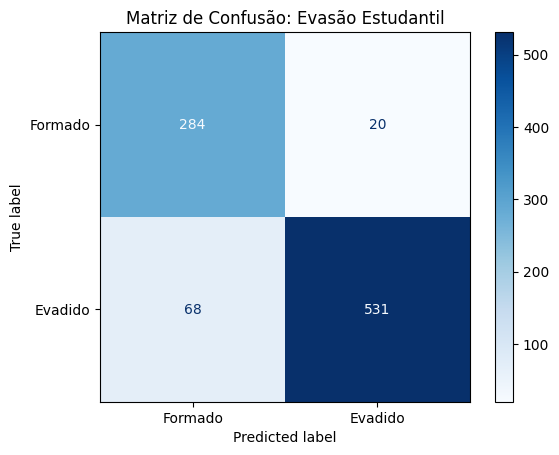

In [1023]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = cat.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("\n--- Métricas Detalhadas ---")
print(classification_report(y_test, y_pred, target_names=['Formado (0)', 'Evadido (1)']))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Formado', 'Evadido'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão: Evasão Estudantil')
plt.show()

In [1077]:
feature_importance

array([ 0.10926995,  0.42610847,  0.50235093,  0.59510573,  0.61021075,
        0.73874083,  0.84278215,  1.05034228,  1.23648512,  1.63907508,
        1.76681723,  1.95353042,  2.3238916 ,  2.33546931,  3.85211176,
        6.84832812,  7.80764918,  9.05596126, 56.30576983])

In [1078]:
feature_importance = cat.get_feature_importance()
feature_importance.sort()
feature_names = X.columns

# Display feature importance
for name, importance in zip(feature_names, feature_importance):
    print(f"Feature: {name}, Importance: {importance:.2f}")

Feature: IMI, Importance: 0.16
Feature: Tipo de demanda, Importance: 0.38
Feature: Idade_Ingresso, Importance: 0.39
Feature: Idade_Academica, Importance: 0.69
Feature: Reprovação_Media_Semestral, Importance: 0.84
Feature: Tempo_Permanencia_Em_Semestres, Importance: 1.01
Feature: Lag_Academico_Em_Semestres, Importance: 1.04
Feature: Lag_Academico_Delta, Importance: 1.33
Feature: Coeficiente_Rendimento, Importance: 1.47
Feature: Coeficiente_Rendimento_Delta, Importance: 1.73
Feature: Modalidade_Ensino, Importance: 1.91
Feature: Eficiencia_Academica, Importance: 2.08
Feature: Eficiencia_Academica_Lag_03, Importance: 2.31
Feature: Eficiencia_Academica_Lag_02, Importance: 3.30
Feature: Eficiencia_Academica_Lag_01, Importance: 3.83
Feature: Rolling_Reprovacao_Media_3_Semestres, Importance: 6.64
Feature: Total_Falhas_Gatekeeper_Acumulado, Importance: 6.83
Feature: Frequencia_Trend, Importance: 7.76
Feature: Frequencia_Rolling_3S, Importance: 56.29


In [1079]:
feats = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

feats = feats.sort_values(by='Importance', ascending=False)
feats.to_csv('features_importance.csv', index=False)

In [1080]:
# get the latest column of the active student
df_inference = df_full_sorted_ativos.sort_values(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])
df_latest_active = df_inference.groupby('RGA_Anon').tail(1).copy()

# same cleaning for the training
cat_features = X_train.columns[X_train.dtypes == 'object'].tolist() # Ou a lista que você usou
df_latest_active[cat_features] = df_latest_active[cat_features].fillna("Nao_Informado").astype(str)

# align columns
X_inference = df_latest_active[X_train.columns]

In [1081]:
from catboost import Pool


inference_pool = Pool(
    data=X_inference, 
    cat_features=cat_features
)


probabilities = cat.predict_proba(inference_pool)[:, 1]

shap_values = cat.get_feature_importance(
    data=inference_pool, 
    type="ShapValues"
)


In [1082]:
# ranking
df_ranking = pd.DataFrame({
    'RGA_Anon': df_latest_active['RGA_Anon'],
    'Probabilidade_Evasao': probabilities
}).sort_values(by='Probabilidade_Evasao', ascending=False)

df_ranking['Nivel_Alerta'] = pd.cut(
    df_ranking['Probabilidade_Evasao'], 
    bins=[0, 0.4, 0.7, 1.0], 
    labels=['Baixo', 'Moderado', 'Critico']
)

print(df_ranking.head(10))

                                              RGA_Anon  Probabilidade_Evasao  \
684  7cfc1c514e185303c3171c49b50ea7071f373194c0f56c...              0.996683   
726  fe758a0a157e4139281677caaffde720c112465434982b...              0.996148   
734  8346f4265b94e141edc60f04aacbf4576a0cd55985633c...              0.996143   
588  dbd5eaab24bfd494bef913ac1238a8da581fdd481f1a61...              0.996135   
388  6b8c9ba1fd64fbb29734f479566f47882f4699321ffe23...              0.996001   
135  a2735f090fd8ac8270354b064b1a2a943fb63700847420...              0.995688   
46   417ab6dd9e907e2d7c6be415dce467ffd89aaffa52fee5...              0.995434   
827  1dc8f7eafa7a59825e380fa1016d7107373303149f4825...              0.995404   
721  e2a704bbfe0084c7cd666e72b41326e341a8089902c346...              0.995278   
265  a4bb9f5aa667c73248c964fa87b61376f69aad5b24b9ba...              0.995094   

    Nivel_Alerta  
684      Critico  
726      Critico  
734      Critico  
588      Critico  
388      Critico  
135  

In [1083]:
k = df_ranking.groupby('Nivel_Alerta').size().reset_index()
k

/tmp/ipykernel_24/3677651213.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  k = df_ranking.groupby('Nivel_Alerta').size().reset_index()


,Nivel_Alerta,0
0,Baixo,82
1,Moderado,8
2,Critico,99


In [1084]:
rga = df_ranking.iloc[0, 0]
rga

'7cfc1c514e185303c3171c49b50ea7071f373194c0f56ceeef9fa828bdc6f151'

In [1090]:
aluno = df_history_v14 [df_history_v14['RGA_Anon'] ==rga]
aluno

,CH,Crédito,Nota,Situação,Nome_Disciplina,Semestre,Frequencia,Falta_Excessiva,Percentual_Faltas,Qtd_Disciplinas_Semestre,Total_CH_Semestre,MG_Semestre,RGA_Anon,Parcela,AnoSem,Período ingresso,Estrutura,Situação atual,Reprovacao_Ponderada_Semestral,Reprovação_Media_Semestral,Tempo_Permanencia_Em_Semestres,Total_creditos_estrutura,Total_Creditos_Acumulados,Idade_Academica,Lag_Academico,Lag_Academico_Em_Semestres,Lag_Academico_Delta,Coeficiente_Rendimento,Coeficiente_Rendimento_Delta,Modalidade_Ensino,Eficiencia_Academica,Eficiencia_Academica_Lag_03,Eficiencia_Academica_Lag_02,Eficiencia_Academica_Lag_01,Rolling_Reprovacao_Media_3_Semestres,Reprovou_Gatekeeper_Puro,Total_Falhas_Gatekeeper_Acumulado,Frequencia_Trend,Frequencia_Rolling_3S
9900,32,2,0.0,1,ELETRONICA BASICA,2,100.000000,0,0.000000,5,320,0.14,7cfc1c514e185303c3171c49b50ea7071f373194c0f56c...,0.2,2024.2,2024.2,20241,AFASTAMENTO POR BLOQUEIO DE MATRICULA,20.0,1.0,1.0,210,20,0.761905,0.238095,0.238095,0.0,0.14,0.0,Presencial,0.761905,NaN,NaN,NaN,1.0,0,2,NaN,37.083333
9901,64,4,0.0,1,LOGICA DIGITAL,2,18.750000,1,0.812500,5,320,0.14,7cfc1c514e185303c3171c49b50ea7071f373194c0f56c...,0.2,2024.2,2024.2,20241,AFASTAMENTO POR BLOQUEIO DE MATRICULA,20.0,1.0,1.0,210,20,0.761905,0.238095,0.238095,0.0,0.14,0.0,Presencial,0.761905,NaN,NaN,NaN,1.0,0,2,NaN,37.083333
9902,64,4,0.0,1,MATEMATICA DISCRETA,2,43.750000,1,0.562500,5,320,0.14,7cfc1c514e185303c3171c49b50ea7071f373194c0f56c...,0.2,2024.2,2024.2,20241,AFASTAMENTO POR BLOQUEIO DE MATRICULA,20.0,1.0,1.0,210,20,0.761905,0.238095,0.238095,0.0,0.14,0.0,Presencial,0.761905,NaN,NaN,NaN,1.0,0,2,NaN,37.083333
9903,64,4,0.7,1,PROGRAMACAO DE COMPUTADORES,2,18.750000,1,0.812500,5,320,0.14,7cfc1c514e185303c3171c49b50ea7071f373194c0f56c...,0.2,2024.2,2024.2,20241,AFASTAMENTO POR BLOQUEIO DE MATRICULA,20.0,1.0,1.0,210,20,0.761905,0.238095,0.238095,0.0,0.14,0.0,Presencial,0.761905,NaN,NaN,NaN,1.0,1,2,NaN,37.083333
9904,96,6,0.0,1,CALCULO DIFERENCIAL E INTEGRAL I,2,4.166667,1,0.958333,5,320,0.14,7cfc1c514e185303c3171c49b50ea7071f373194c0f56c...,0.2,2024.2,2024.2,20241,AFASTAMENTO POR BLOQUEIO DE MATRICULA,20.0,1.0,1.0,210,20,0.761905,0.238095,0.238095,0.0,0.14,0.0,Presencial,0.761905,NaN,NaN,NaN,1.0,1,2,NaN,37.083333


In [1089]:
aluno[['Lag_Academico_Em_Semestres']]

,Lag_Academico_Em_Semestres
9900,0.238095
9901,0.238095
9902,0.238095
9903,0.238095
9904,0.238095
